# NUS Datathon -- Category B

Team: **Afternoon DSA**

In [ ]:
import pandas as pd
import numpy as np
import re, json, math
from pathlib import Path
from datetime import datetime

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib

from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler

DATA_PATH = Path("C:/Users\Aaron\Downloads\sds_datathon_gradsingapore.xlsx") ##this is the working directory of the dataset
OUT_DIR = Path("outputs")
FIG_DIR = OUT_DIR / "figures"
OUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_excel(DATA_PATH)
print(df.shape)
df.head()


<>:23: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
<>:23: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
C:\Users\Aaron\AppData\Local\Temp\ipykernel_17748\576858674.py:23: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
  DATA_PATH = Path("C:/Users\Aaron\Downloads\sds_datathon_gradsingapore.xlsx")


(2614, 32)


,Response ID,Time Started,Date Submitted,Status,Language,SessionID,User Agent,Tags,IP Address,Longitude,...,Types of roles available:What do you wish to learn more about regarding the organisation as an employer? (Pick 3),Career progression and development:What do you wish to learn more about regarding the organisation as an employer? (Pick 3),Compensation and benefits:What do you wish to learn more about regarding the organisation as an employer? (Pick 3),Work-life balance and culture:What do you wish to learn more about regarding the organisation as an employer? (Pick 3),Application and interview process:What do you wish to learn more about regarding the organisation as an employer? (Pick 3),Other - Write In (Required):What do you wish to learn more about regarding the organisation as an employer? (Pick 3),Other - Write In (Required):What do you wish to learn more about regarding the organisation as an employer? (Pick 3) .1,"On a scale from 1 to 10 (1 – Low, 10 – High), how would you rate the attractiveness of the organisation as an employer?",Which of these factors would most motivate you to apply for a position at the organisation?,Other - Write In (Required):Which of these factors would most motivate you to apply for a position at the organisation?
0,19,2025-09-02 15:03:01,2025-09-02 15:03:40,Partial,English,1756796577_68b696a123dd27.81295289,Mozilla/5.0 (iPhone; CPU iPhone OS 18_6_2 like...,NaN,104.28.119.112,-97.821999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20,2025-09-02 15:15:32,2025-09-02 15:16:59,Disqualified,English,1756797328_68b699901c4cf6.89118890,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,NaN,57.140.24.26,4.344700,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,21,2025-09-02 15:18:01,2025-09-02 15:19:30,Disqualified,English,1756797478_68b69a26c5d785.44808899,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,NaN,57.140.24.26,4.344700,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,22,2025-09-03 15:25:18,2025-09-03 15:27:05,Complete,English,1756884314_68b7ed5a14f861.00788803,Mozilla/5.0 (Linux; Android 15; K) AppleWebKit...,NaN,119.234.8.156,103.839302,...,Types of roles available,Career progression and development,NaN,NaN,Application and interview process,NaN,NaN,8.0,Meaningful work impact,NaN
4,23,2025-09-03 15:34:31,2025-09-03 15:34:31,Partial,English,1756884864_68b7ef80372683.27687311,Mozilla/5.0 (iPhone; CPU iPhone OS 18_5 like M...,NaN,194.11.199.111,-77.644302,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df = df.copy()

# Parse datetimes
for c in ["Time Started", "Date Submitted"]:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")

# Standardise status
df["Status_clean"] = df["Status"].astype(str).str.strip().str.lower()
df["is_complete"] = df["Status_clean"].str.contains("complete")

# Convenience
meta_cols = ["Response ID","Time Started","Date Submitted","Status","Status_clean","is_complete",
             "Language","SessionID","User Agent","Tags","IP Address","Longitude","Latitude",
             "Country","City","State/Region","Postal"]
meta_cols = [c for c in meta_cols if c in df.columns]

question_cols = [c for c in df.columns if c not in meta_cols]
print("Meta cols:", len(meta_cols), "Question cols:", len(question_cols))

Meta cols: 17 Question cols: 17


## 1) Survey quality diagnostics

We prioritise questions for improvement using:
- **Missingness rate** (non-response)
- **Redundancy signals** (Cramer's V)


In [ ]:

miss = (
    df[question_cols].isna()
    | df[question_cols].astype(str).apply(lambda col: col.str.strip().eq(""))
).mean().sort_values(ascending=False)

top_miss = miss.head(12).reset_index()
top_miss.columns = ["question", "missing_rate"]
top_miss



,question,missing_rate
0,Other - Write In (Required):What do you wish t...,0.998087
1,Other - Write In (Required):What do you wish t...,0.998087
2,Other - Write In (Required):Which of these fac...,0.997322
3,Application and interview process:What do you ...,0.795715
4,Work-life balance and culture:What do you wish...,0.611706
5,Compensation and benefits:What do you wish to ...,0.544759
6,Career progression and development:What do you...,0.469396
7,Types of roles available:What do you wish to l...,0.459449
8,"On a scale from 1 to 10 (1 – Low, 10 – High), ...",0.293037
9,Which of these factors would most motivate you...,0.293037


C:\Users\Aaron\AppData\Local\Temp\ipykernel_17748\244572440.py:29: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


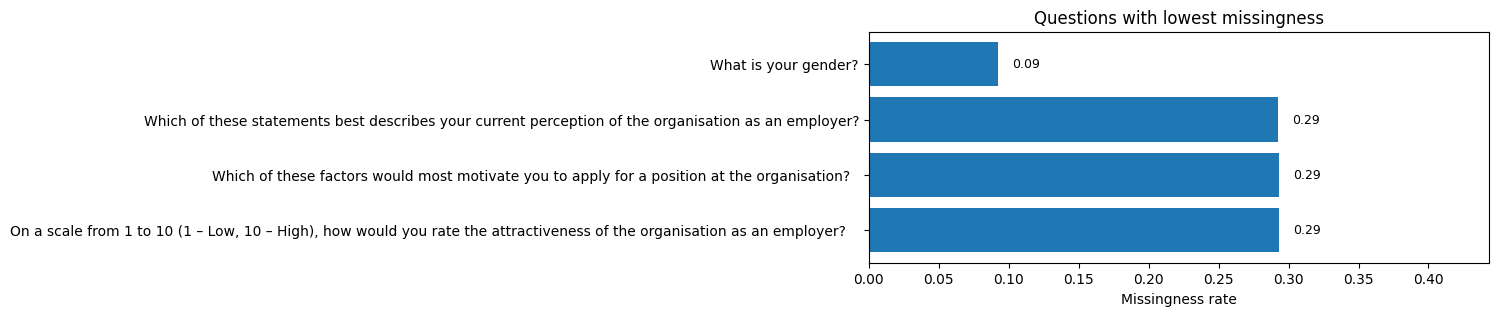

In [ ]:
import matplotlib.pyplot as plt

# Remove the "Pick 3" and "others" inputs
bottom4 = top_miss.tail(4)

plt.figure(figsize=(8, 3))
bars = plt.barh(
    bottom4["question"],
    bottom4["missing_rate"]
)

plt.xlabel("Missingness rate")
plt.title("Questions with lowest missingness")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01,                      
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va="center",
        ha="left",
        fontsize=9
    )

plt.xlim(0, max(bottom4["missing_rate"]) + 0.15)
plt.tight_layout()
plt.show()


In [ ]:
# Cramer's V 
from scipy.stats import chi2_contingency


def cramers_v(x, y):
    tab = pd.crosstab(x, y)
    if tab.shape[0] < 2 or tab.shape[1] < 2:
        return np.nan
    chi2 = chi2_contingency(tab, correction=False)[0]
    n = tab.to_numpy().sum()
    r, k = tab.shape
    return np.sqrt((chi2 / n) / (min(k-1, r-1)))


cat_candidates = []
for c in question_cols:
    s = df[c]
    
    nunique = s.dropna().astype(str).nunique()
    if nunique >= 2 and nunique <= 25 and "scale" not in c.lower():
        cat_candidates.append(c)


pairs = []

for i in range(len(cat_candidates)):
    for j in range(i + 1, len(cat_candidates)):
        a, b = cat_candidates[i], cat_candidates[j]

        v = cramers_v(
            df[a].astype(str),
            df[b].astype(str)
        )

        if pd.notna(v) and 0.25 <= v < 0.95:
            pairs.append({
                "q1": a,
                "q2": b,
                "cramers_v": round(float(v), 3)
            })

redundancy = (
    pd.DataFrame(pairs)
    .sort_values("cramers_v", ascending=False)
    .head(12)
)

redundancy


,q1,q2,cramers_v
0,Which higher education institution do you or d...,What will be your highest qualification when y...,0.287
1,Which higher education institution do you or d...,Which of the following best describes the main...,0.262


## 2) Completion propensity (factors associated with incomplete responses)

We surfaced the **top positive/negative drivers** correlated with completion.


In [ ]:
from sklearn.impute import SimpleImputer

y = df["is_complete"].astype(int)


early_candidates = []


for key in [
    "institution",
    "year of study",
    "highest qualification",
    "main subject",
    "nationality",
    "gender",
    "perception"
]:
    early_candidates += [c for c in df.columns if key in c.lower()]


for c in ["Country", "City", "State/Region", "Language", "User Agent"]:
    if c in df.columns:
        early_candidates.append(c)

feature_cols = list(dict.fromkeys([c for c in early_candidates if c in df.columns]))
X = df[feature_cols].copy()


for c in feature_cols:
    X[c] = X[c].fillna("__MISSING__").astype(str).str.strip()


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), feature_cols),
    ],
    remainder="drop"
)

pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=2000, solver="lbfgs"))
])

pipe.fit(X_train, y_train)


proba = pipe.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, proba)

baseline = y_test.mean()
print("\nBaseline completion rate (test):", round(float(baseline), 3))


ohe = pipe.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"]
feat_names = ohe.get_feature_names_out(feature_cols)

coefs = pipe.named_steps["model"].coef_.ravel()
coef_df = pd.DataFrame({
    "feature": feat_names,
    "coef": coefs,
    "odds_ratio": np.exp(coefs)
})

top_pos = coef_df.sort_values("coef", ascending=False).head(10)
top_neg = coef_df.sort_values("coef", ascending=True).head(10)

print("\nTop drivers increasing completion probability (odds ratio):")
display(top_pos[["feature", "coef", "odds_ratio"]])

print("\nTop drivers decreasing completion probability (odds ratio):")
display(top_neg[["feature", "coef", "odds_ratio"]])

df_risk = df[feature_cols].copy()
for c in feature_cols:
    df_risk[c] = df_risk[c].fillna("__MISSING__").astype(str).str.strip()

df_risk["p_complete"] = pipe.predict_proba(df_risk)[:, 1]
df_risk["is_complete"] = y.values


MIN_N = 20  

def find_col(df, pattern):
    """Find the first column whose name matches pattern (case-insensitive)."""
    pat = re.compile(pattern, re.IGNORECASE)
    matches = [c for c in df.columns if pat.search(c)]
    if not matches:
        raise KeyError(f"No column matched pattern: {pattern}")
    return matches[0]


col_year = find_col(df, r"current year of study")
col_subject = find_col(df, r"(main subject)|(best describes.*subject)|(subject that you are studying)")

segment_dims = [col_year, col_subject]
print("Using segment columns:", segment_dims)

seg_df = df[segment_dims].copy()
for c in segment_dims:
    seg_df[c] = seg_df[c].fillna("__MISSING__").astype(str).str.strip()


seg_df["p_complete"] = pipe.predict_proba(X)[:, 1]
seg_df["is_complete"] = y.values


seg_summary = (
    seg_df
    .groupby(segment_dims)
    .agg(
        n=("p_complete", "size"),
        avg_p_complete=("p_complete", "mean"),
        completion_rate=("is_complete", "mean"),
    )
    .reset_index()
)


seg_summary_stable = (
    seg_summary
    .query("n >= @MIN_N")
    .sort_values("avg_p_complete")
    .reset_index(drop=True)
)

print(f"\nShowing segments with n ≥ {MIN_N}")
seg_summary_stable.head(15)





Baseline completion rate (test): 0.706

Top drivers increasing completion probability (odds ratio):


,feature,coef,odds_ratio
61,Please indicate your nationality._Singaporean/...,1.872228,6.502771
67,Which of these statements best describes your ...,1.793675,6.011504
68,Which of these statements best describes your ...,1.780450,5.932526
69,Which of these statements best describes your ...,1.565127,4.783282
32,What will be your highest qualification when y...,1.273688,3.574008
70,Which of these statements best describes your ...,1.113801,3.045914
30,What is your current year of study as of 2025?...,0.318532,1.375108
27,What is your current year of study as of 2025?...,0.272572,1.313338
12,Which higher education institution do you or d...,0.270242,1.310282
196,User Agent_Mozilla/5.0 (Windows NT 10.0; Win64...,0.258516,1.295007



Top drivers decreasing completion probability (odds ratio):


,feature,coef,odds_ratio
71,Which of these statements best describes your ...,-6.110014,0.002221
158,User Agent_Mozilla/5.0 (Linux; Android 15; K) ...,-1.034232,0.355499
59,Please indicate your nationality._Non-Singapor...,-0.837497,0.432792
60,Please indicate your nationality._Non-Singapor...,-0.738747,0.477712
18,Which higher education institution do you or d...,-0.591486,0.553504
26,What is your current year of study as of 2025?...,-0.527730,0.589943
36,What will be your highest qualification when y...,-0.456911,0.633237
40,Which of the following best describes the main...,-0.417407,0.658752
34,What will be your highest qualification when y...,-0.299439,0.741234
33,What will be your highest qualification when y...,-0.166709,0.846446


Using segment columns: ['What is your current year of study as of 2025?', 'Which of the following best describes the main subject that you are studying?\xa0']

Showing segments with n ≥ 20


,What is your current year of study as of 2025?,Which of the following best describes the main subject that you are studying?,n,avg_p_complete,completion_rate
0,__MISSING__,__MISSING__,240,0.000873,0.000000
1,Year 3,Economics,20,0.413124,0.400000
2,Year 1,IT and Technology,53,0.605064,0.603774
3,Year 1,Mathematical Science/Statistics,145,0.607308,0.606897
4,Year 3,Mathematical Science/Statistics,81,0.643475,0.641975
5,Year 3,"Engineering (Electrical/Electronics, Mechanica...",32,0.662887,0.656250
6,Year 2,IT and Technology,54,0.684306,0.685185
7,Year 2,Mathematical Science/Statistics,128,0.718142,0.718750
8,Year 1,"Natural Science (Physics, Chemistry, Biology, ...",197,0.735877,0.736041
9,Year 1,"Architecture, Building and Planning",23,0.739812,0.739130


## 3) Data Cleaning to remove disqualified and partially done surveys
hehe

In [ ]:

pd.set_option("display.max_columns", 200)
plt.rcParams["figure.dpi"] = 120

import pandas as pd

df1 = df[df["Status"] == "Complete"]

columns_to_drop = [
    "Language",
    "SessionID",
    "IP Address",
    "Longitude",
    "Latitude",
    "City",
    "State/Region",
    "Postal"
]

df_clean = df1.drop(columns=columns_to_drop, errors="ignore")

print(df_clean.shape)
df_clean.head(10)

(1848, 26)


,Response ID,Time Started,Date Submitted,Status,User Agent,Tags,Country,Which higher education institution do you or did you study at?,What is your current year of study as of 2025?,What will be your highest qualification when you graduate?,Which of the following best describes the main subject that you are studying?,Please indicate your nationality.,What is your gender?,Which of these statements best describes your current perception of the organisation as an employer?,Types of roles available:What do you wish to learn more about regarding the organisation as an employer? (Pick 3),Career progression and development:What do you wish to learn more about regarding the organisation as an employer? (Pick 3),Compensation and benefits:What do you wish to learn more about regarding the organisation as an employer? (Pick 3),Work-life balance and culture:What do you wish to learn more about regarding the organisation as an employer? (Pick 3),Application and interview process:What do you wish to learn more about regarding the organisation as an employer? (Pick 3),Other - Write In (Required):What do you wish to learn more about regarding the organisation as an employer? (Pick 3),Other - Write In (Required):What do you wish to learn more about regarding the organisation as an employer? (Pick 3) .1,"On a scale from 1 to 10 (1 – Low, 10 – High), how would you rate the attractiveness of the organisation as an employer?",Which of these factors would most motivate you to apply for a position at the organisation?,Other - Write In (Required):Which of these factors would most motivate you to apply for a position at the organisation?,Status_clean,is_complete
3,22,2025-09-03 15:25:18,2025-09-03 15:27:05,Complete,Mozilla/5.0 (Linux; Android 15; K) AppleWebKit...,NaN,Singapore,Nanyang Technological University (NTU),Year 4,Bachelor's Degree,Economics,Singaporean/Singapore PR,Female,I’m familiar with the organisation and would c...,Types of roles available,Career progression and development,NaN,NaN,Application and interview process,NaN,NaN,8.0,Meaningful work impact,NaN,complete,True
9,28,2025-09-04 13:25:41,2025-09-04 17:50:12,Complete,Mozilla/5.0 (iPhone; CPU iPhone OS 18_6_2 like...,NaN,Singapore,Nanyang Technological University (NTU),Year 3,Bachelor's Degree,"Business/Management (Accounting, Finance, Mark...",Singaporean/Singapore PR,Female,"I recognise the organisation by name, but don’...",NaN,Career progression and development,Compensation and benefits,Work-life balance and culture,NaN,NaN,NaN,6.0,Meaningful work impact,NaN,complete,True
13,32,2025-09-04 15:18:25,2025-09-04 15:19:23,Complete,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,Singapore,Nanyang Technological University (NTU),Year 3,Bachelor's Degree,"Business/Management (Accounting, Finance, Mark...",Singaporean/Singapore PR,Female,I have a general positive impression of the or...,NaN,Career progression and development,Compensation and benefits,Work-life balance and culture,NaN,NaN,NaN,7.0,Career growth opportunities,NaN,complete,True
16,35,2025-09-05 00:38:26,2025-10-16 13:56:34,Complete,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,Singapore,Nanyang Technological University (NTU),Year 2,Bachelor's Degree,Psychology,Singaporean/Singapore PR,Female,I have a general positive impression of the or...,NaN,Career progression and development,Compensation and benefits,Work-life balance and culture,NaN,NaN,NaN,5.0,Meaningful work impact,NaN,complete,True
17,36,2025-09-05 14:34:27,2025-09-05 14:36:52,Complete,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,NaN,Singapore,Singapore Management University (SMU),Year 2,Bachelor's Degree,"Business/Management (Accounting, Finance, Mark...",Singaporean/Singapore PR,Female,"I recognise the organisation by name, but don’...",Types of roles available,Career progression and development,Compensation and benefits,NaN,NaN,NaN,NaN,8.0,Meaningful work impact,NaN,complete,True
20,39,2025-09-05 14:41:45,2025-09-05 14:43:13,Complete,Mozilla/5.0 (

In [ ]:
# Robust, efficient and dynamic column assigning
rating_col = [c for c in df_clean.columns if c.startswith("On a scale from 1 to 10")][0]
motivation_col = [c for c in df_clean.columns if c.startswith("Which of these factors would most motivate")][0]
pick3_cols = [c for c in df_clean.columns if "Pick 3" in c]

rename = {
    "Which higher education institution do you or did you study at?": "institution",
    "What is your current year of study as of 2025?": "year",
    "What will be your highest qualification when you graduate?": "qualification",
    "Which of the following best describes the main subject that you are studying?\xa0": "subject",
    "Please indicate your nationality.": "nationality",
    "What is your gender?": "gender",
    "Which of these statements best describes your current perception of the organisation as an employer?": "perception",
    rating_col: "rating",
    motivation_col: "motivation",
    pick3_cols[0]: "learn_roles",
    pick3_cols[1]: "learn_career",
    pick3_cols[2]: "learn_comp",
    pick3_cols[3]: "learn_wlb",
    pick3_cols[4]: "learn_process",
    pick3_cols[5]: "learn_other_flag",
    pick3_cols[6]: "learn_other_text",
}

d = df_clean.rename(columns=rename).copy()
d["rating"] = pd.to_numeric(d["rating"], errors="coerce")

learn_bin_cols = ["learn_roles","learn_career","learn_comp","learn_wlb","learn_process"]
for c in learn_bin_cols:
    d[c] = d[c].notna().astype(int)

d["learn_other"] = d["learn_other_text"].notna().astype(int)
d["learn_count"] = d[learn_bin_cols + ["learn_other_flag","learn_other_text"]].notna().sum(axis=1)

d.head(6)


,Response ID,Time Started,Date Submitted,Status,User Agent,Tags,Country,institution,year,qualification,subject,nationality,gender,perception,learn_roles,learn_career,learn_comp,learn_wlb,learn_process,learn_other_flag,learn_other_text,rating,motivation,Other - Write In (Required):Which of these factors would most motivate you to apply for a position at the organisation?,Status_clean,is_complete,learn_other,learn_count
3,22,2025-09-03 15:25:18,2025-09-03 15:27:05,Complete,Mozilla/5.0 (Linux; Android 15; K) AppleWebKit...,NaN,Singapore,Nanyang Technological University (NTU),Year 4,Bachelor's Degree,Economics,Singaporean/Singapore PR,Female,I’m familiar with the organisation and would c...,1,1,0,0,1,NaN,NaN,8.0,Meaningful work impact,NaN,complete,True,0,5
9,28,2025-09-04 13:25:41,2025-09-04 17:50:12,Complete,Mozilla/5.0 (iPhone; CPU iPhone OS 18_6_2 like...,NaN,Singapore,Nanyang Technological University (NTU),Year 3,Bachelor's Degree,"Business/Management (Accounting, Finance, Mark...",Singaporean/Singapore PR,Female,"I recognise the organisation by name, but don’...",0,1,1,1,0,NaN,NaN,6.0,Meaningful work impact,NaN,complete,True,0,5
13,32,2025-09-04 15:18:25,2025-09-04 15:19:23,Complete,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,Singapore,Nanyang Technological University (NTU),Year 3,Bachelor's Degree,"Business/Management (Accounting, Finance, Mark...",Singaporean/Singapore PR,Female,I have a general positive impression of the or...,0,1,1,1,0,NaN,NaN,7.0,Career growth opportunities,NaN,complete,True,0,5
16,35,2025-09-05 00:38:26,2025-10-16 13:56:34,Complete,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,Singapore,Nanyang Technological University (NTU),Year 2,Bachelor's Degree,Psychology,Singaporean/Singapore PR,Female,I have a general positive impression of the or...,0,1,1,1,0,NaN,NaN,5.0,Meaningful work impact,NaN,complete,True,0,5
17,36,2025-09-05 14:34:27,2025-09-05 14:36:52,Complete,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,NaN,Singapore,Singapore Management University (SMU),Year 2,Bachelor's Degree,"Business/Management (Accounting, Finance, Mark...",Singaporean/Singapore PR,Female,"I recognise the organisation by name, but don’...",1,1,1,0,0,NaN,NaN,8.0,Meaningful work impact,NaN,complete,True,0,5
20,39,2025-09-05 14:41:45,2025-09-05 14:43:13,Complete,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,NaN,Singapore,Singapore Management University (SMU),Year 2,Bachelor's Degree,Economics,Singaporean/Singapore PR,Female,I have a general positive impression of the or...,1,1,1,0,0,NaN,NaN,10.0,Career growth opportunities,NaN,complete,True,0,5


n = 1848
Average rating: 6.28
Median rating: 6.0


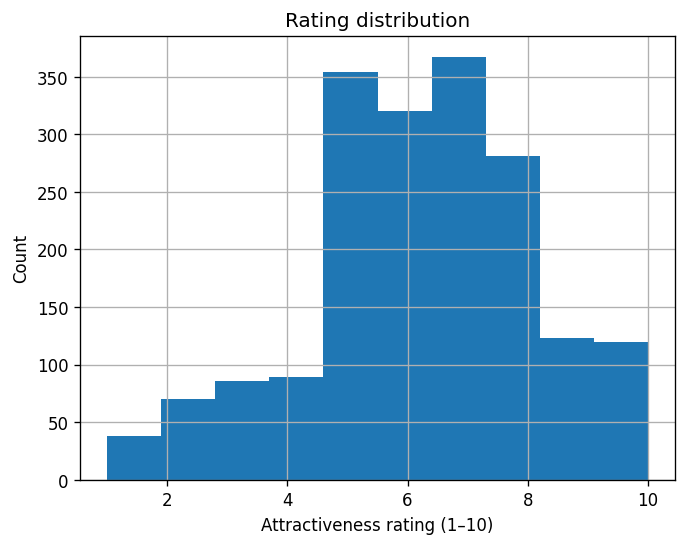

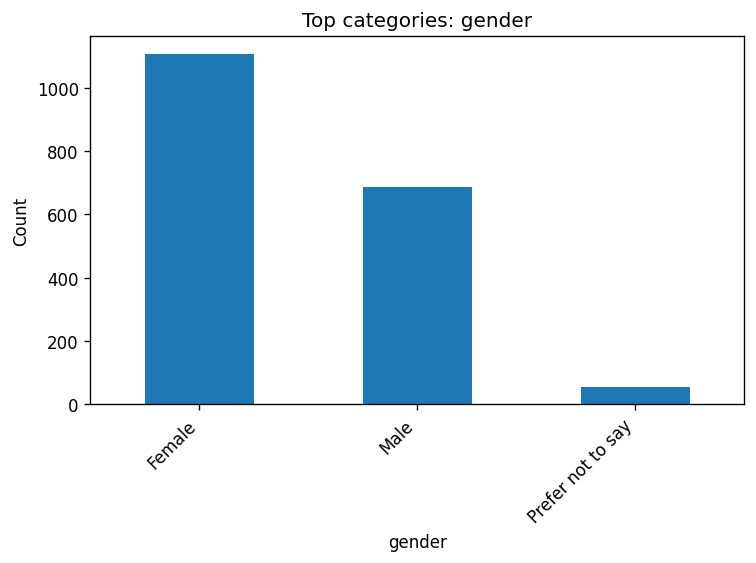

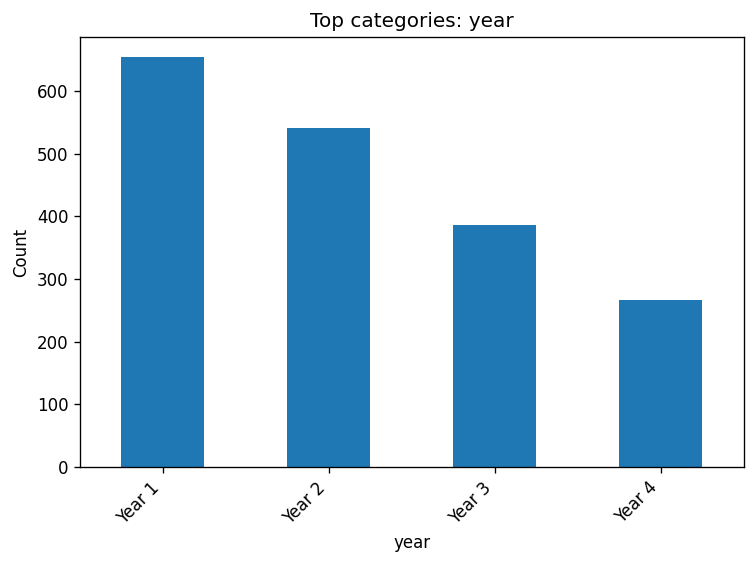

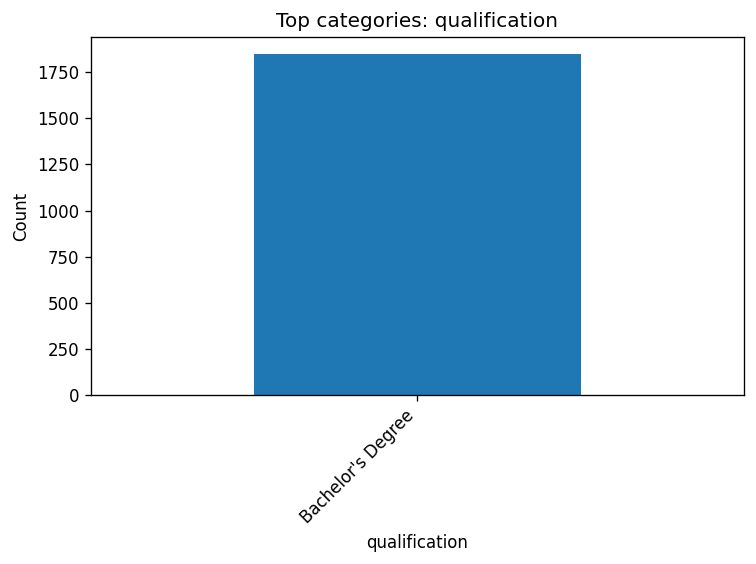

C:\Users\Aaron\AppData\Local\Temp\ipykernel_17748\767747517.py:20: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


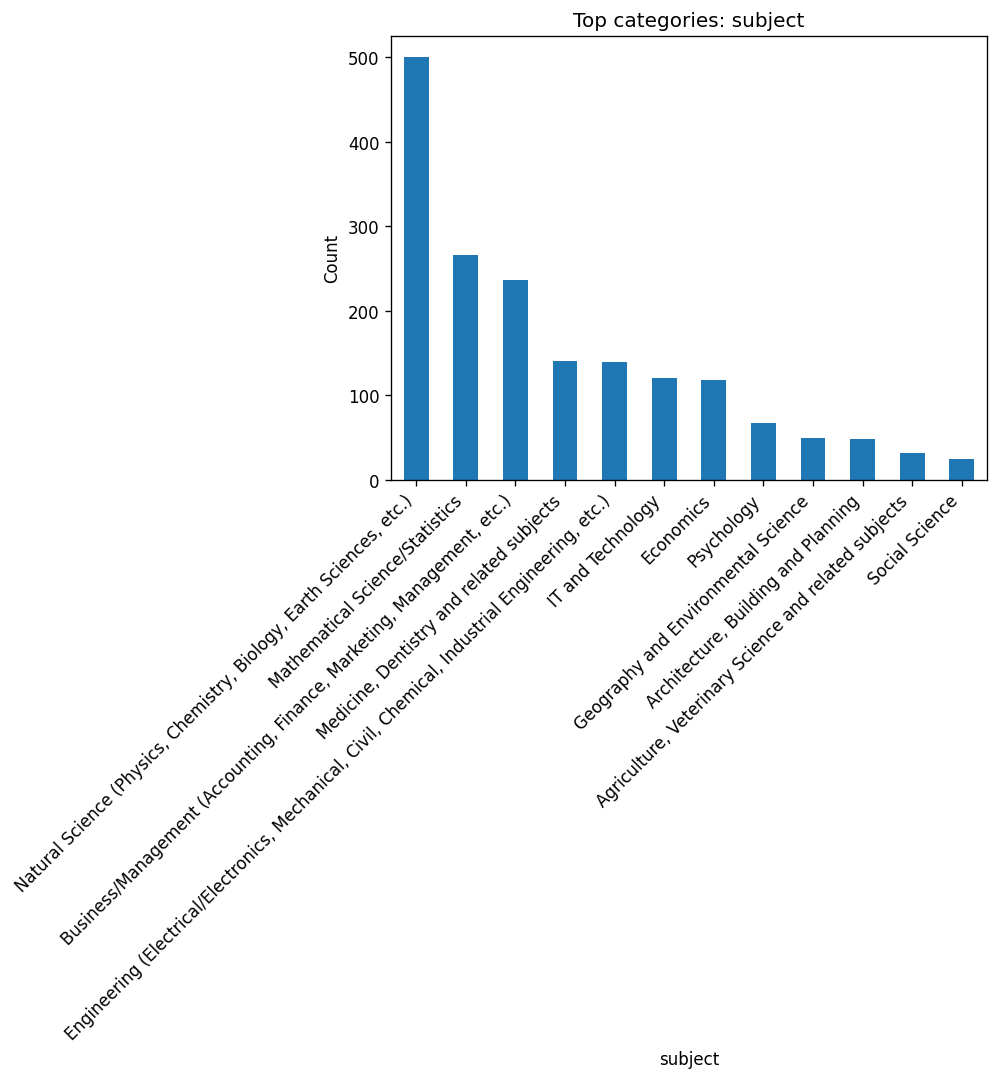

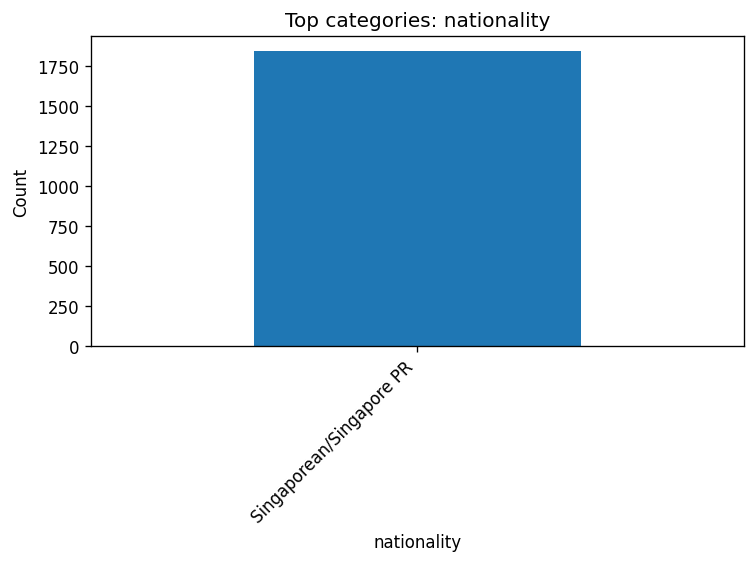

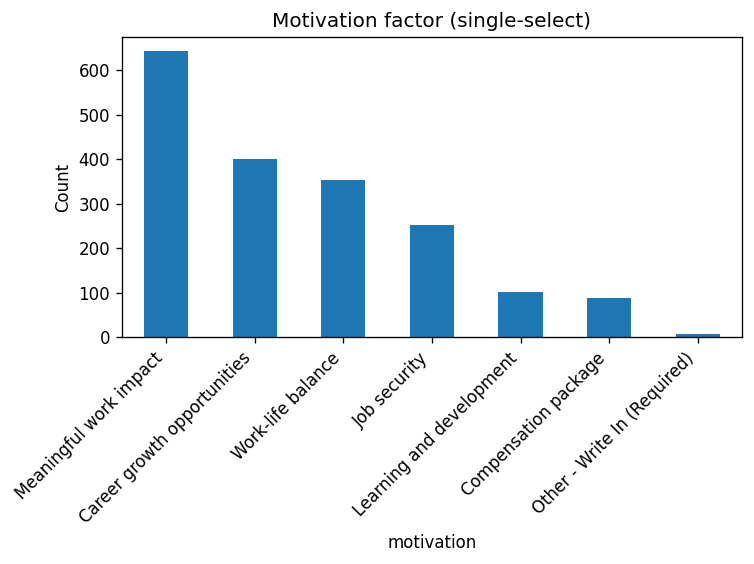

In [ ]:
##1) EDA
# -------------------------
print("n =", len(d))
print("Average rating:", round(d["rating"].mean(), 3))
print("Median rating:", float(d["rating"].median()))

plt.figure()
d["rating"].hist(bins=10)
plt.xlabel("Attractiveness rating (1–10)")
plt.ylabel("Count")
plt.title("Rating distribution")
plt.show()

for col in ["gender","year","qualification","subject","nationality"]:
    plt.figure()
    d[col].value_counts(dropna=False).head(12).plot(kind="bar")
    plt.title(f"Top categories: {col}")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

plt.figure()
d["motivation"].value_counts().plot(kind="bar")
plt.title("Motivation factor (single-select)")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
d["learn_count"].value_counts().sort_index()

edge = d[d["learn_count"] != 3][[
    "learn_roles","learn_career","learn_comp","learn_wlb","learn_process",
    "learn_other_flag","learn_other_text"
]]
edge.head(10)

,learn_roles,learn_career,learn_comp,learn_wlb,learn_process,learn_other_flag,learn_other_text
3,1,1,0,0,1,NaN,NaN
9,0,1,1,1,0,NaN,NaN
13,0,1,1,1,0,NaN,NaN
16,0,1,1,1,0,NaN,NaN
17,1,1,1,0,0,NaN,NaN
20,1,1,1,0,0,NaN,NaN
21,1,0,1,1,0,NaN,NaN
26,0,1,1,1,0,NaN,NaN
27,1,1,0,1,0,NaN,NaN
29,1,1,0,0,1,NaN,NaN


In [ ]:
#Cramer's V
def cramers_v(x, y):
    tab = pd.crosstab(x, y)
    if tab.size == 0:
        return np.nan
    chi2 = chi2_contingency(tab, correction=False)[0]
    n = tab.sum().sum()
    phi2 = chi2 / n
    r, k = tab.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    denom = min((kcorr-1), (rcorr-1))
    return np.sqrt(phi2corr/denom) if denom > 0 else np.nan

cat_vars = ["institution","year","qualification","subject","nationality","gender","perception","motivation"]
V = pd.DataFrame(index=cat_vars, columns=cat_vars, dtype=float)
for i,a in enumerate(cat_vars):
    for j,b in enumerate(cat_vars):
        if j < i:
            V.loc[a,b] = cramers_v(d[a], d[b])

V.round(3)

,institution,year,qualification,subject,nationality,gender,perception,motivation
institution,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,0.155,NaN,NaN,NaN,NaN,NaN,NaN,NaN
qualification,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subject,0.259,0.171,NaN,NaN,NaN,NaN,NaN,NaN
nationality,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,0.198,0.014,NaN,0.174,NaN,NaN,NaN,NaN
perception,0.129,0.029,NaN,0.167,NaN,0.099,NaN,NaN
motivation,0.098,0.055,NaN,0.061,NaN,0.063,0.093,NaN


C:\Users\Aaron\AppData\Local\Temp\ipykernel_17748\3194711199.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


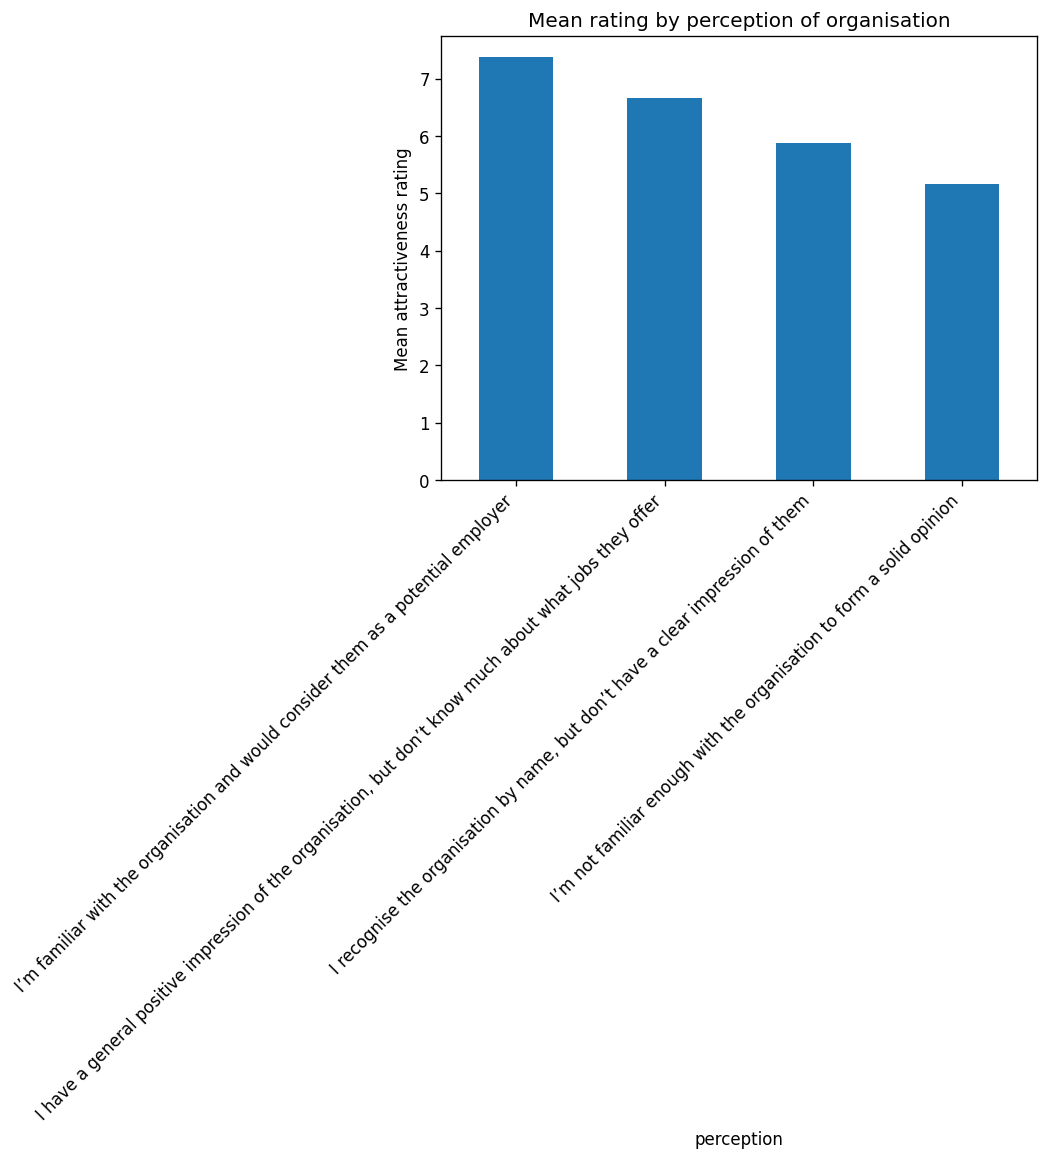

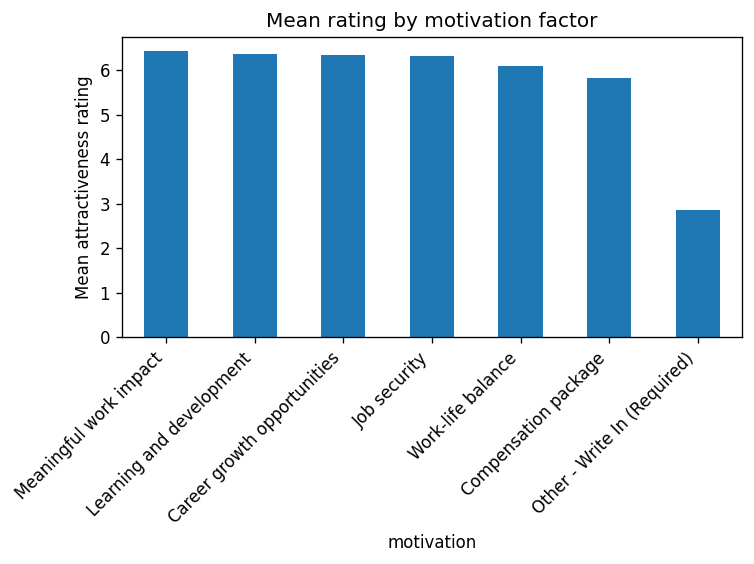

learn_roles      0.764610
learn_career     0.750541
learn_comp       0.643939
learn_wlb        0.549242
learn_process    0.288961
learn_other      0.002706
dtype: float64

In [ ]:
# Employer attractiveness insights (applicant perspective)

rating_by_perception = d.groupby("perception")["rating"].agg(["count","mean"]).sort_values("mean", ascending=False)
rating_by_perception

plt.figure()
rating_by_perception["mean"].plot(kind="bar")
plt.title("Mean rating by perception of organisation")
plt.ylabel("Mean attractiveness rating")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

rating_by_motivation = d.groupby("motivation")["rating"].agg(["count","mean"]).sort_values("mean", ascending=False)
rating_by_motivation

plt.figure()
rating_by_motivation["mean"].plot(kind="bar")
plt.title("Mean rating by motivation factor")
plt.ylabel("Mean attractiveness rating")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

learn_rates = d[learn_bin_cols + ["learn_other"]].mean().sort_values(ascending=False)
learn_rates

                        n  mean_rating
combo                                 
career|process|roles  149     6.818792
career|process|wlb     57     6.666667
career|comp|process    53     6.471698
career|comp|roles     557     6.378815
career|comp|wlb       237     6.261603
career|roles|wlb      331     6.232628
process|roles|wlb     117     6.128205
comp|process|wlb       87     6.034483
comp|process|roles     71     6.028169
comp|roles|wlb        184     5.836957


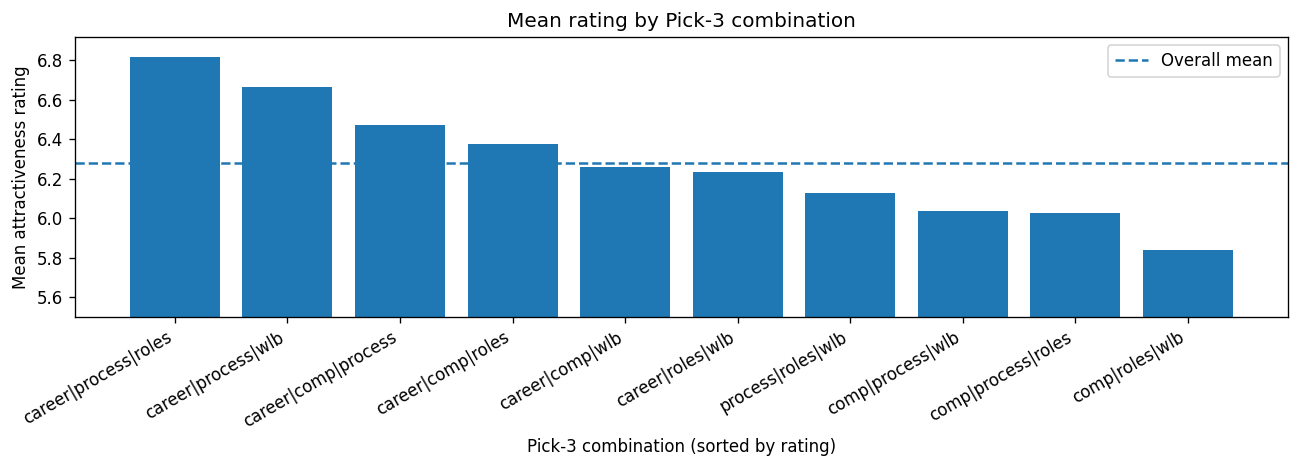

In [ ]:
from itertools import combinations

pick_cols = {
    "roles": "learn_roles",
    "career": "learn_career",
    "comp": "learn_comp",
    "wlb": "learn_wlb",
    "process": "learn_process",
}
rating_col = "rating"
ymin = 5.5


dfp = d.copy()

# Keep valid Pick-3 rows
pick_col_list = list(pick_cols.values())
dfp = dfp[dfp[pick_col_list].sum(axis=1) == 3].copy()

def pick3_combo(row):
    selected = [name for name, col in pick_cols.items() if row[col] == 1]
    return "|".join(sorted(selected))

dfp["combo"] = dfp.apply(pick3_combo, axis=1)

# Aggregate mean rating
combo_stats = (
    dfp.groupby("combo")[rating_col]
       .agg(n="count", mean_rating="mean")
)

all_combos = [
    "|".join(sorted(c))
    for c in combinations(pick_cols.keys(), 3)
]
combo_stats = combo_stats.reindex(all_combos)

# Sort by mean rating (descending)
combo_stats = combo_stats.sort_values("mean_rating", ascending=False)

print(combo_stats)

# Plot (break in y-axis)
plt.figure(figsize=(11, 4))
plt.bar(combo_stats.index, combo_stats["mean_rating"])
plt.axhline(d[rating_col].mean(), linestyle="--", label="Overall mean")

plt.ylim(ymin, combo_stats["mean_rating"].max() + 0.1)
plt.ylabel("Mean attractiveness rating")
plt.xlabel("Pick-3 combination (sorted by rating)")
plt.title("Mean rating by Pick-3 combination")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.show()




## END